**Virtual mass air flow sensor**


A virtual MAF sensor is a software-based system that calculates the volume and density of air entering an engine using mathematical models rather than relying on a physical hardware MAF sensor.

A  virtual MAF doesn’t directly measure passing air but it rather collects data from other sensors in the car(Manifold Absolute Pressure, throttle position, RPM(s), etc).

To understand why a virtual MAF is useful we first have to look at how the physical sensor worked.

.Physical MAF sensor worked by placing an electrically heated wire at the air intake track. As air passed over the wire, it cooled down. Now the ECU measured the amount of current that was  used to keep the wire hot as it cooled down.

.Virtual MAF sensor now lacks the wire but now the ECU is preprogrammed to look at data from alternative sensors to predict the mass of air in the engine.

Now the big question is why use a Virtual MAF sensor yet there is an already existing and working sensor. Here are  some of the reasons why:

1.It works as backup and a fail safe – in modern cars today the physical sensor is still present but it is vulnerable to contamination by oil, water and dust. The virtual sensor thus acts in some way as a “sanity checker” for readings from the physical sensor and can take over from the physical sensor if need be.

2.Cost reduction – physical sensors are expensive components thus their elimination reduces production costs.

3.No maintenance or wear – physical sensors are easily damaged by oil, dirt or debris passing through the air which can cause loss of power or rough idling whereas a virtual MAF has little to no maintenance.


We first have to start by importing the necessary libraries

In [1]:
%pip install pandas
import pandas as pd
import numpy as np
%pip install matplotlib
import matplotlib.pyplot as plt
%pip install seaborn #used to create statistical graphs 
import seaborn as sns
#import warnings #manages alert messages when code runs
#warnings.filterwarnings('ignore') #done to avoid clutter 

#ensures that all my plots are static and occur below my code cells(no pop up windows)
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#used': Expected package name at the start of dependency specifier
    #used
    ^


Note: you may need to restart the kernel to use updated packages.


pathlib provides a modern oriented way to interact with the file 
Importing the data to our notebook while merging all of it to one big dataframe.

In [2]:
from pathlib import Path


filename = "2017-07-05_Seat_Leon_RT_S_Stau.csv"
matches = list(Path.cwd().rglob(filename)) # checks the current working directory(cwd) and all subdirectories to find any file matchng filename

if not matches:
    raise FileNotFoundError(
        f"{filename} was not found. Current working directory: {Path.cwd()}"
    ) #checks if list is empty.if file wasn't found it stops execution and throws an error

df = pd.read_csv(matches[0]) #reads first matched path into a pandas dataframe
df.head()


#Grab every CsV in that folder
csv_files = list(Path.cwd().rglob("OBD-II-Dataset/**/*.csv"))  # deeply searches for all .csv files in OBD-||-Dataset(even subdirectories)
print(f"Found {len(csv_files)} files") # total number of csv files sound

dfs=[] # starts an empty list used before a loop to load and append each CSV to a list of dataframes for merging 
for f in csv_files:
    temp = pd.read_csv(f) #reads current csv file to a temp dataframe
    temp['source_file'] = f.stem # adds ccolumns source_file containing file base name with no .csv extension
    dfs.append(temp) #adds each dataframe into the dfs list

df = pd.concat(dfs, ignore_index=True) #merges all individual dataframes into one big dataframe
print(df.shape) 
df.head()

Found 84 files
(2797502, 15)


,Time,Engine Coolant Temperature [Â°C],Intake Manifold Absolute Pressure [kPa],Engine RPM [RPM],Vehicle Speed Sensor [km/h],Intake Air Temperature [Â°C],Air Flow Rate from Mass Flow Sensor [g/s],Absolute Throttle Position [%],Ambient Air Temperature [Â°C],Accelerator Pedal Position D [%],Accelerator Pedal Position E [%],source_file,Engine Coolant Temperature [°C],Intake Air Temperature [°C],Ambient Air Temperature [°C]
0,07:16:30.444,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-07-05_Seat_Leon_RT_S_Stau - Copy - Copy,NaN,NaN,NaN
1,07:16:30.535,31.0,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-07-05_Seat_Leon_RT_S_Stau - Copy - Copy,NaN,NaN,NaN
2,07:16:30.625,31.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-07-05_Seat_Leon_RT_S_Stau - Copy - Copy,NaN,NaN,NaN
3,07:16:30.716,31.0,96.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2017-07-05_Seat_Leon_RT_S_Stau - Copy - Copy,NaN,NaN,NaN
4,07:16:30.814,31.0,96.0,0.0,0.0,22.0,NaN,NaN,NaN,NaN,NaN,2017-07-05_Seat_Leon_RT_S_Stau - Copy - Copy,NaN,NaN,NaN


**Cell interpratation**
-The csv files were all found thanks to .cwd and .rglob.
-The data merging was needed since the data was in different files thus .cwd and .rglob had to be used to recursively search the directory and subdirectories before merging.After merging the resulting dataframe builds a new clean index from 0 to n.
-A total number of rows and columns is is given to confirm every csv file was found
-The first 5 rows are printed to show how the dataframe looks like.

We then have to clean and consolidate mangled or duplicate column names which were caused by merging datasets with different degree ssymbols.
We are not handling non-null vales just the dplicate columns for now caused by the difference in encoding from windows and visual studio codegroups 

In [3]:
from collections import defaultdict

def normalize_col(col):
    return col.replace('Â°', '°').strip()  # replaces the windows encoding corruption('Â°' back to '°')

groups = defaultdict(list)
for col in df.columns:
    groups[normalize_col(col)].append(col)  #groups duplicate columns that now have the same name

for norm_name, cols in groups.items():
    if len(cols) > 1:
        merged = df[cols[0]]
        for c in cols[1:]:
            merged = merged.combine_first(df[c])
        df[norm_name] = merged
        drop_cols = [c for c in cols if c != norm_name]
        df = df.drop(columns=drop_cols)#merges the data across duplicate columns,saves the merged result to the clean column name and removes the duplicates

df.isna().sum() 


Time                                           0
Intake Manifold Absolute Pressure [kPa]       91
Engine RPM [RPM]                             175
Vehicle Speed Sensor [km/h]                  249
Air Flow Rate from Mass Flow Sensor [g/s]    417
Absolute Throttle Position [%]               501
Accelerator Pedal Position D [%]             678
Accelerator Pedal Position E [%]             752
source_file                                    0
Engine Coolant Temperature [°C]                7
Intake Air Temperature [°C]                  333
Ambient Air Temperature [°C]                 585
dtype: int64

**Cell interpratation**

The output now sums up the number  of missing values from each clean column for the next step of data cleaning.

Due to how large our dataset is I decide there is no risk in dropping rows rather imputation which would be tiresome.

In [4]:
df =df.dropna()
print(df.shape)
df.head()
df.isna().sum()


(2796738, 12)


Time                                         0
Intake Manifold Absolute Pressure [kPa]      0
Engine RPM [RPM]                             0
Vehicle Speed Sensor [km/h]                  0
Air Flow Rate from Mass Flow Sensor [g/s]    0
Absolute Throttle Position [%]               0
Accelerator Pedal Position D [%]             0
Accelerator Pedal Position E [%]             0
source_file                                  0
Engine Coolant Temperature [°C]              0
Intake Air Temperature [°C]                  0
Ambient Air Temperature [°C]                 0
dtype: int64

**Cell interpratation**

-The rows are now dropped thus no missing values.\
-The shape of the dataframe is printed out to know how many columns and rows were lost.
-The columns are printed out to confirm that we now have no null values in our dataframe.

In [5]:
df.columns

Index(['Time', 'Intake Manifold Absolute Pressure [kPa]', 'Engine RPM [RPM]',
       'Vehicle Speed Sensor [km/h]',
       'Air Flow Rate from Mass Flow Sensor [g/s]',
       'Absolute Throttle Position [%]', 'Accelerator Pedal Position D [%]',
       'Accelerator Pedal Position E [%]', 'source_file',
       'Engine Coolant Temperature [°C]', 'Intake Air Temperature [°C]',
       'Ambient Air Temperature [°C]'],
      dtype='str')

In [6]:
df.info()  # gives summary of a dataframe 

<class 'pandas.DataFrame'>
Index: 2796738 entries, 9 to 2797501
Data columns (total 12 columns):
 #   Column                                     Dtype  
---  ------                                     -----  
 0   Time                                       str    
 1   Intake Manifold Absolute Pressure [kPa]    float64
 2   Engine RPM [RPM]                           float64
 3   Vehicle Speed Sensor [km/h]                float64
 4   Air Flow Rate from Mass Flow Sensor [g/s]  float64
 5   Absolute Throttle Position [%]             float64
 6   Accelerator Pedal Position D [%]           float64
 7   Accelerator Pedal Position E [%]           float64
 8   source_file                                str    
 9   Engine Coolant Temperature [°C]            float64
 10  Intake Air Temperature [°C]                float64
 11  Ambient Air Temperature [°C]               float64
dtypes: float64(10), str(2)
memory usage: 277.4 MB


In [7]:
df['Intake Manifold Absolute Pressure [kPa]'].max()
df.dtypes #check columns are integers or floats
df.duplicated().sum() #check for duplicates per row
df = df.sort_values(['source_file', 'Time']).reset_index(drop=True)
df.describe()#checks for the impossible

,Intake Manifold Absolute Pressure [kPa],Engine RPM [RPM],Vehicle Speed Sensor [km/h],Air Flow Rate from Mass Flow Sensor [g/s],Absolute Throttle Position [%],Accelerator Pedal Position D [%],Accelerator Pedal Position E [%],Engine Coolant Temperature [°C],Intake Air Temperature [°C],Ambient Air Temperature [°C]
count,2.796738e+06,2.796738e+06,2.796738e+06,2.796738e+06,2.796738e+06,2.796738e+06,2.796738e+06,2.796738e+06,2.796738e+06,2.796738e+06
mean,1.250549e+02,1.490458e+03,6.172547e+01,2.254581e+01,8.129868e+01,2.162523e+01,2.194353e+01,8.154783e+01,1.972521e+01,1.047080e+01
std,3.118803e+01,5.318707e+02,4.556291e+01,1.622411e+01,1.118852e+01,1.259526e+01,1.263029e+01,1.808829e+01,1.940701e+01,1.121988e+01
min,3.600000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.370000e+01,1.410000e+01,1.410000e+01,-1.000000e+00,-4.000000e+01,-1.400000e+01
25%,1.040000e+02,1.104000e+03,1.800000e+01,1.155000e+01,8.350000e+01,1.410000e+01,1.450000e+01,8.600000e+01,7.000000e+00,0.000000e+00
50%,1.140000e+02,1.534000e+03,5.900000e+01,1.852000e+01,8.350000e+01,1.410000e+01,1.450000e+01,9.000000e+01,1.900000e+01,1.300000e+01
75%,1.360000e+02,1.841000e+03,1.010000e+02,2.894000e+01,8.350000e+01,2.670000e+01,2.710000e+01,9.100000e+01,2.800000e+01,2.000000e+01
max,2.470000e+02,4.315000e+03,2.180000e+02,1.292200e+02,8.900000e+01,8.510000e+01,8.430000e+01,1.030000e+02,1.500000e+02,3.300000e+01


In [8]:
df.dtypes #check columns are integers or floats
df.duplicated().sum() #check for duplicates per row


np.int64(0)

In [9]:
print("Shape:", df.shape)#size of the dataframe
print(df.head())#prints the first 5 rows of the dataframe

Shape: (2796738, 12)
           Time  Intake Manifold Absolute Pressure [kPa]  Engine RPM [RPM]  \
0  07:16:31.257                                     96.0               0.0   
1  07:16:31.345                                     96.0               0.0   
2  07:16:31.435                                     96.0               0.0   
3  07:16:31.525                                     96.0               0.0   
4  07:16:31.615                                     96.0               0.0   

   Vehicle Speed Sensor [km/h]  Air Flow Rate from Mass Flow Sensor [g/s]  \
0                          0.0                                       0.91   
1                          0.0                                       0.91   
2                          0.0                                       0.91   
3                          0.0                                       0.91   
4                          0.0                                       0.91   

   Absolute Throttle Position [%]  Accelerator 

In [10]:
 #features for the classical mls are picked from the columns we had.
features=[
    'Intake Manifold Absolute Pressure [kPa]',
    'Engine RPM [RPM]',
    'Vehicle Speed Sensor [km/h]',
    'Absolute Throttle Position [%]',
    #'Accelerator Pedal Position D [%]',
    'Accelerator Pedal Position E [%]',
    'Engine Coolant Temperature [°C]',
    'Intake Air Temperature [°C]',
    'Ambient Air Temperature [°C]',
]
target= 'Air Flow Rate from Mass Flow Sensor [g/s]'

x = df[features]
y = df[target]

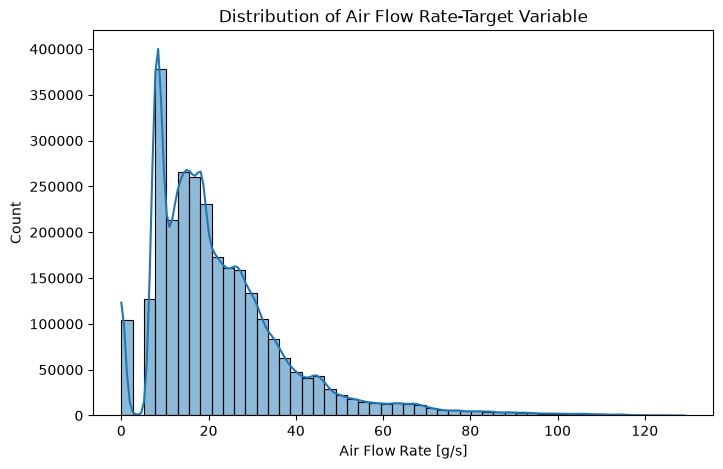

In [11]:
#Target distribution-histogram is used to know the shape of the target variable and to check for skewness or outliers. It helps in understanding the distribution of the target variable, which can influence the choice of modeling techniques and preprocessing steps.    
plt.figure(figsize=(8, 5)) # picks grid for the graph
sns.histplot(df[target], bins=50, kde=True)
plt.title('Distribution of Air Flow Rate-Target Variable')
plt.xlabel('Air Flow Rate [g/s]')
plt.ylabel('Count')
plt.show()

**Graph interpratation**

-The graph is a right-skewed histogram that has a multimodal distribution.Due to the multimodal distribution, tree-based models can be used since they handle multimodality and skewed targets.Linear regression models can be used but will underperform due to the target being strongly skewed and non-Gaussian(data that doesn't follow bell-shaped curve)

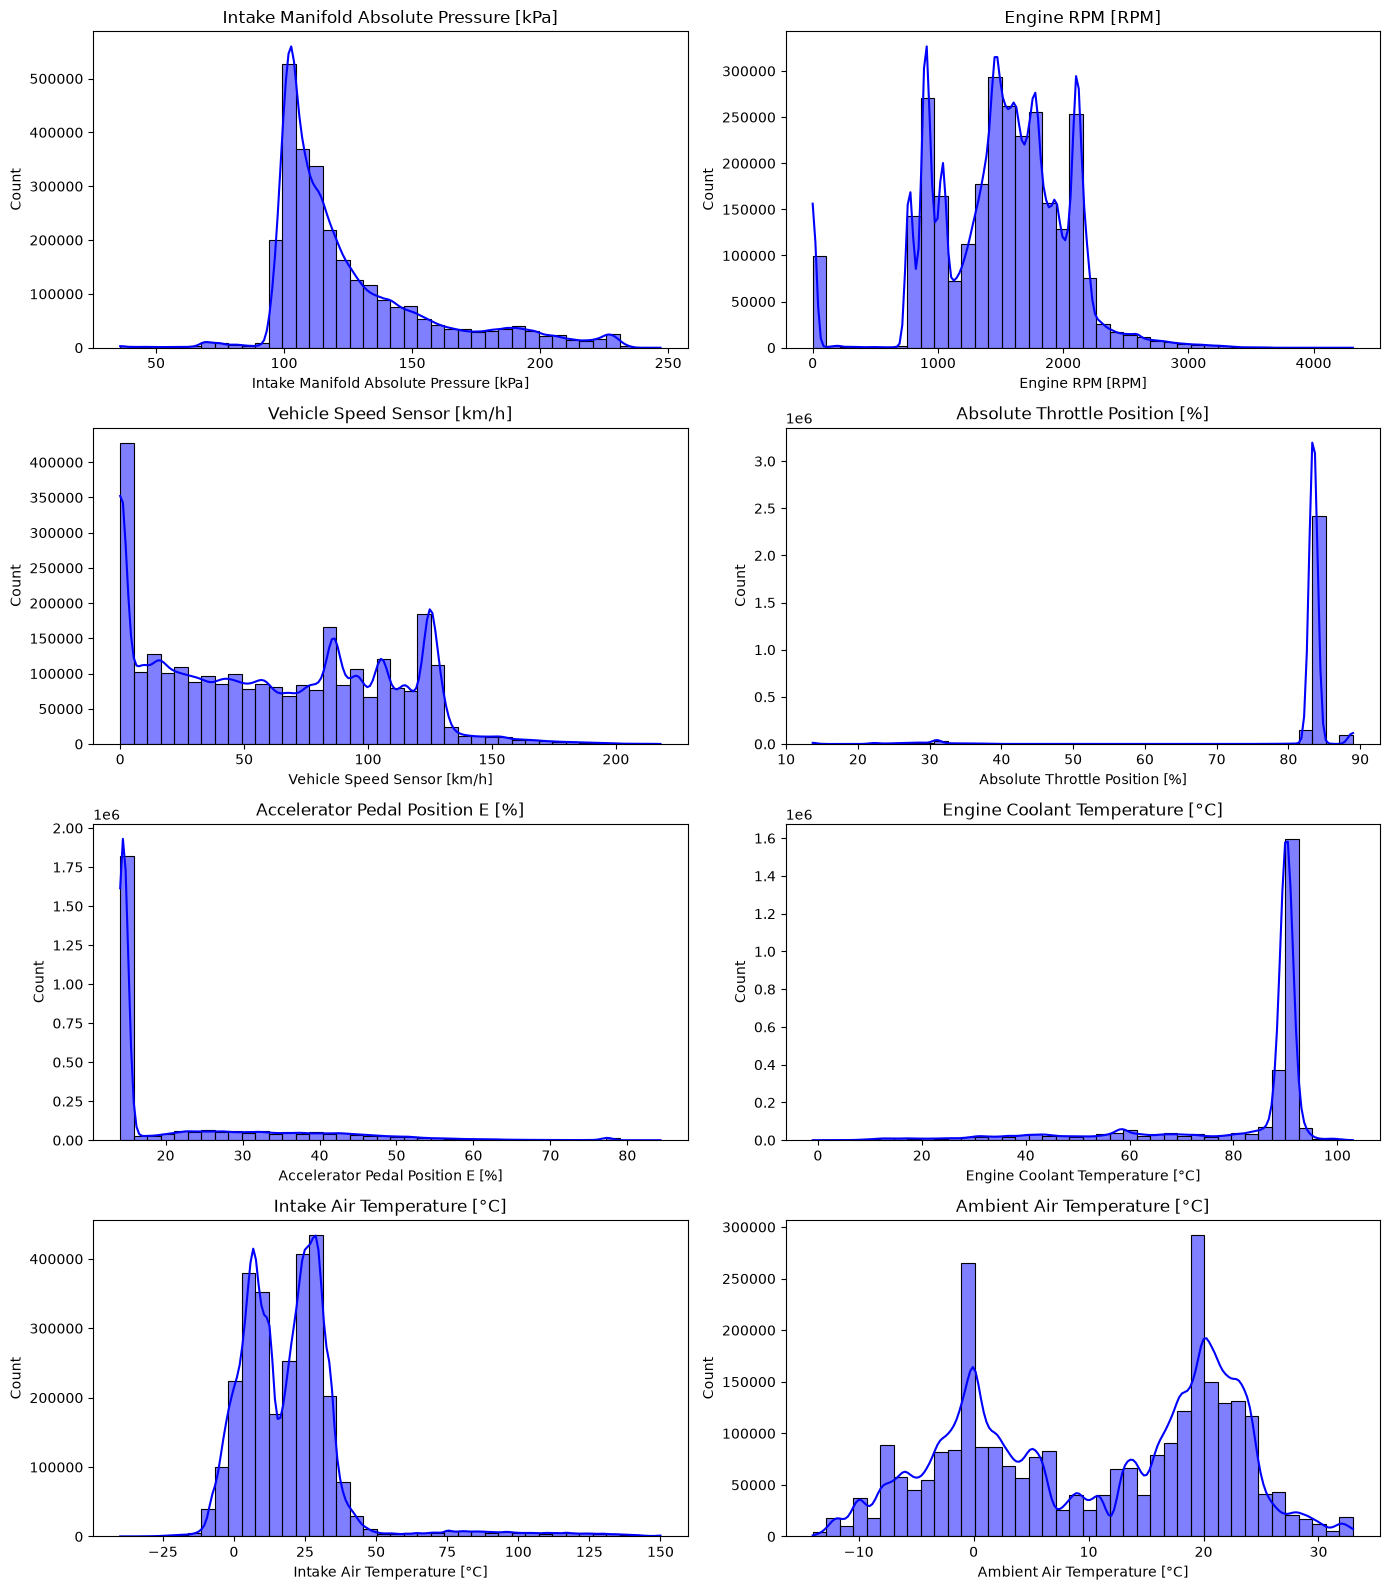

In [12]:
#Feature distribution-helps spot sensors thatare not working properly or have a lot of noise. It helps in understanding the distribution of the features, which can influence feature selection and preprocessing steps.
fig,axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=40,ax=axes[i], color='blue', kde=True)
    axes[i].set_title(feature)
plt.tight_layout()
plt.show()

**Feature graph  interpratation**

-The Intake Manifold Absolute Pressure graph has ambient atmospheric pressure going upto 230kPa thus indicating forced induction induction(turbocharger or supercharger).

-The graphs indicate that there are some features to drop due to the near-zero variance.Features such as :

1.Absolute throttle position-millions of data points sit at 85-88%

2.Engine coolant Temperature- can be kept only for cold starting since engines maintain a set temperature when running thus this feature has little to no variance.

-Features that are to be kept are :

1.Engine RPM - a high priority feature since air mass has a linear relationship with engine speed since as the engine spins faster more air is needed.

2.Intake Manifold Absolute Pressure - manifold pressure directly determines how much air gets crammed into the engine's cylinders.

3.Accelerator Pedal Position E - captures your foot moving the gas pedal tells the ECU what the driver is to do before the engine reacts and changes its airflow.

4.Intake air temperature - this means that hot air and cold air changes the mass of air entering the engine due to air density.

-There are features to consider whether to add or not due to their redundancy such as:

1.Ambient air temp - high collinearity to Intake Air Temperature

2.Vehicle Speed Sensor - since cars can go the exact same speed under completely different engine workloads(gears).


In [13]:
#checking for collinearity in columns for acceleator pedal position D and E
print(df[['Accelerator Pedal Position D [%]', 'Accelerator Pedal Position E [%]']].corr())
#had to drop one column because they are highly correlated. I dropped Accelerator Pedal Position D [%] and kept Accelerator Pedal Position E [%]

                                  Accelerator Pedal Position D [%]  \
Accelerator Pedal Position D [%]                          1.000000   
Accelerator Pedal Position E [%]                          0.984833   

                                  Accelerator Pedal Position E [%]  
Accelerator Pedal Position D [%]                          0.984833  
Accelerator Pedal Position E [%]                          1.000000  


At training and testing splits we use groupshuffle split since the dataset consists of seperated driving sessions each in a file. Groushuffle split is also used to keep all rows from the same session together in either train or test to avoid data leakage.

In [16]:
# Ensure the package exists in this notebook environment before importing it
%pip install scikit-learn

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)# initializes group splitter for 1 split,seeded with random 42 for reproducability

# Ensure the package exists in this notebook environment before importing it
%pip install scikit-learn


gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Create a sample dataset if it was not already defined in a previous cell
if "df_sample" not in globals():
    df_sample = df.iloc[::9].copy().reset_index(drop=True)

train_idx, test_idx = next(
    gss.split(
        df_sample[features],
        df_sample[target],
        groups=df_sample["source_file"]
    )
)

# data is split into training and testing while ensuring data from the same source file
# is not mixed between train and test splits.
X_train = df_sample.iloc[train_idx][features]
X_test = df_sample.iloc[test_idx][features]
y_train = df_sample.iloc[train_idx][target]
y_test = df_sample.iloc[test_idx][target]

# Show the result
print("Train sessions:", df_sample.iloc[train_idx]['source_file'].nunique())
print("Test sessions:", df_sample.iloc[test_idx]['source_file'].nunique())#data is split into training and testing while ensuring data from the s the same source file is not mixed btwn train and test splits.

X_train = df_sample.iloc[train_idx][features] #selects feature columns for training
X_test = df_sample.iloc[test_idx][features] # selects feature columns for test set 
y_train = df_sample.iloc[train_idx][target] # selects target columns for training
y_test = df_sample.iloc[test_idx][target] #selects target columns for testing


# Show the result
print("Train sessions:", df.iloc[train_idx]['source_file'].nunique())
print("Test sessions:", df.iloc[test_idx]['source_file'].nunique())



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Train sessions: 67
Test sessions: 17
Train sessions: 9
Test sessions: 8


**Cell interpratation**

-The dataset is split into train and test sets using a cross validation strategy that ensures data from the same source file is not mixed between train and test splits. 

In [17]:
#Random sample that is selected from the 9th row of my dataframe due to how large the dataset is and the computers RAM
df_sample = df.iloc[::9] #

x=df_sample[features]
y=df_sample[target]

In [18]:
# Check sample size and split balance
print(f"Downsampled dataset rows: {len(df_sample)}")
print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(f"Downsample ratio: {len(df_sample) / len(df):.3f}")
print(f"Train share: {len(X_train) / len(df_sample):.3f}")
print(f"Test share: {len(X_test) / len(df_sample):.3f}")


Downsampled dataset rows: 310749
Training rows: 244673
Testing rows: 66076
Downsample ratio: 0.111
Train share: 0.787
Test share: 0.213


** Classical ML introoduction**

-We now introduce our classical ML(s) starting with the RandomForestRegressor,XGBoost,Linear SVR and Light GBM.

-All my models are to use MSE,R2 and RMSE as their metrics.

-Accuracy can't be used since its for classification while my output is for continuous    airflow.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

forest_model = RandomForestRegressor(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1)
forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, forest_predictions)))
print("RF R2:", r2_score(y_test, forest_predictions))

RF RMSE: 4.172309682593745
RF R2: 0.935740245759661


**Random forest output**

-The model gave out a positive output suggesting that it had trained and tested well due to the RMSE being low and the r2 beinfg closer to 1.

In [20]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


**XGBoost**

-Used to handle tabular/structured and big datasets.

-Same metrics are used MSE,RMSE and R2

In [21]:
import re #Regular expression provides set of tools for finding,matching and modifying text using specific patterns
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
from xgboost import XGBRegressor


# XGBoost is sensitive to column names with brackets/symbols, so sanitize them.
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()# copies of x_train and x_test made to avoid changing original dataframe

#replaces special characters in column names to prevent a validation error from scikit learn
X_train_xgb.columns = X_train_xgb.columns.map(lambda c: re.sub(r"[\[\]<>]", "_", str(c)))
X_test_xgb.columns = X_test_xgb.columns.map(lambda c: re.sub(r"[\[\]<>]", "_", str(c)))

#Model initialization
xgb_model = XGBRegressor(
    n_estimators=300, #300 boosting trees constructed
    learning_rate=0.05,
    max_depth=6, #restricts each tree to a max depth of 6 split levels tp avoid any fitting 
    objective="reg:squarederror", #uses MSE as optimization targetr
    random_state=42, # seeds in random processes for reproducible execution.
    n_jobs=-1 #Utilizes all CPU cores to speed up tree construction
)

xgb_model.fit(X_train_xgb, y_train)

xgb_predictions = xgb_model.predict(X_test_xgb)
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, xgb_predictions)))
print("XGB R2:", r2_score(y_test, xgb_predictions))




XGB RMSE: 4.189920875426816
XGB R2: 0.9351966239165252


**XGBoost output**

-The model's output was great with a low RMSE and a high R2.

In [22]:
# Clean model comparison table
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [23]:
comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_predictions)),
        "R2": r2_score(y_test, rf_predictions),
    },
    {
        "Model": "XGBoost",
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_predictions)),
        "R2": r2_score(y_test, xgb_predictions),
    }
]).sort_values("RMSE").reset_index(drop=True)

comparison

,Model,RMSE,R2
0,Random Forest,4.172310,0.935740
1,XGBoost,4.189921,0.935197


**Linear SVR**

-This model was used due to the linear relationship between the target and RPM(s),manifold pressure and throttle position.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

svr_model = Pipeline([
    ("scaler", StandardScaler()), #to prevent other features from dominating others since linear SVR relies on distance
    ("svr",LinearSVR(
        C=100, #regularization parameter
        epsilon=0.05, #sets the width of the tube around regression line where no penalty is assigned to prediction errors within 0.05 units of target
        max_iter=10000)) # increases max optimization solver iterations for convergence
])
#Modelling Fitting and Prediction
svr_model.fit(X_train, y_train)
svr_predictions = svr_model.predict(X_test)

print("SVR RMSE:", np.sqrt(mean_squared_error(y_test, svr_predictions)))
print("SVR R2:", r2_score(y_test, svr_predictions))

SVR RMSE: 7.07633591880628
SVR R2: 0.8151570585926777


c:\Users\user\Downloads\Virtual Mass Air Flow Rate Model\.venv\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


**Linear SVR output**

-The model underperformed when compared to the other models but it was mainly a baseine linear model.

In [25]:
comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_predictions)),
        "R2": r2_score(y_test, rf_predictions),
    },
    {
        "Model": "XGBoost",
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_predictions)),
        "R2": r2_score(y_test, xgb_predictions),
    },
    {
        "Model": "SVR",
        "RMSE": np.sqrt(mean_squared_error(y_test, svr_predictions)),
        "R2": r2_score(y_test, svr_predictions),
    }
]).sort_values("RMSE").reset_index(drop=True)

comparison

,Model,RMSE,R2
0,Random Forest,4.172310,0.935740
1,XGBoost,4.189921,0.935197
2,SVR,7.076336,0.815157


In [26]:
%pip install lightgbm

import re
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Make the model
lgbm_model = LGBMRegressor(
    objective="regression", #
    n_estimators=500, # number of trees to have when training
    learning_rate=0.05, #set to improve generalization for more trees to converge
    num_leaves=31, #max number of leaves(terminal nodes) in a tree
    max_depth=-1, #trees grow as deep as they want provided theyfollow leaves
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1, # all CPU cores are used
    verbose=-1 #Suppress output logs,warnings and progress messages during fitting process
)

# Copy the train and test data to not interefere with the actual dataframe
X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

# Clean the column names because LightGBM does not like symbols like [ ] and %
X_train_lgbm.columns = [
    re.sub(r"[^A-Za-z0-9_]+", "_", str(col)).strip("_")
    for col in X_train_lgbm.columns
]
X_test_lgbm.columns = X_train_lgbm.columns

# Trains the model
lgbm_model.fit(X_train_lgbm, y_train)

# Predict on the test data
lgbm_predictions = lgbm_model.predict(X_test_lgbm)

# Show the results
print("LightGBM RMSE:", np.sqrt(mean_squared_error(y_test, lgbm_predictions)))
print("LightGBM R2:", r2_score(y_test, lgbm_predictions))

Note: you may need to restart the kernel to use updated packages.
LightGBM RMSE: 4.140181957684357
LightGBM R2: 0.9367260647567676


In [27]:
# Compare LightGBM alongside Random Forest, XGBoost, and SVR
comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_predictions)),
        "R2": r2_score(y_test, rf_predictions),
    },
    {
        "Model": "XGBoost",
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_predictions)),
        "R2": r2_score(y_test, xgb_predictions),
    },
    {
        "Model": "LightGBM",
        "RMSE": np.sqrt(mean_squared_error(y_test, lgbm_predictions)),
        "R2": r2_score(y_test, lgbm_predictions),
    },
    {
        "Model": "SVR",
        "RMSE": np.sqrt(mean_squared_error(y_test, svr_predictions)),
        "R2": r2_score(y_test, svr_predictions),
    }
]).sort_values("RMSE").reset_index(drop=True)

comparison

,Model,RMSE,R2
0,LightGBM,4.140182,0.936726
1,Random Forest,4.172310,0.935740
2,XGBoost,4.189921,0.935197
3,SVR,7.076336,0.815157


In [ ]:
# Deep learning training setup
# I used MSE as the training loss because the target is a continuous value (air flow rate in g/s).
# I also tracked MAE during training, which tells us the average absolute error in the same units.
# For final model comparison, I used RMSE and R2 on the test set because they are easier to interpret:
# - RMSE: how far the predictions are from the true values (lower is better)
# - R2: how well the model explains the variance in the target (closer to 1 is better)

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# MLP works best when features are on a similar scale.
# The sensor values vary in range, so scaling is important.
scaler = StandardScaler()
X_train_mlp = scaler.fit_transform(X_train.to_numpy())
X_test_mlp = scaler.transform(X_test.to_numpy())

y_train_mlp = y_train.values
y_test_mlp = y_test.values

# I chose a moderate number of layers: 128 -> 64 -> 32.
# This is a simple but still powerful network for tabular sensor data.
# It is deep enough to learn nonlinear relationships, but not so deep that it overfits easily.
# For beginner-level intuition: small, well-structured networks often work better than very deep ones on medium-sized datasets.
model = models.Sequential([
    layers.Input(shape=(X_train_mlp.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# ReLU is used in the hidden layers because it is simple, fast, and helps the network learn nonlinear patterns.
# It is a standard choice in deep learning because it usually avoids the "dead neuron" issue better than sigmoid for hidden layers.
# Early stopping is used with patience=10 so training stops if the validation loss stops improving.
callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# I used 80 epochs because the dataset is not tiny, but we also want to avoid overtraining.
# The early stopping callback helps by ending training when the model stops improving.
history = model.fit(
    X_train_mlp,
    y_train_mlp,
    validation_split=0.1,
    epochs=80,
    batch_size=256,
    callbacks=[callback],
    verbose=0
)

mlp_predictions = model.predict(X_test_mlp, verbose=0).flatten()

mlp_rmse = np.sqrt(mean_squared_error(y_test_mlp, mlp_predictions))
mlp_r2 = r2_score(y_test_mlp, mlp_predictions)

print(f"MLP RMSE: {mlp_rmse:.4f}")
print(f"MLP R2: {mlp_r2:.4f}")


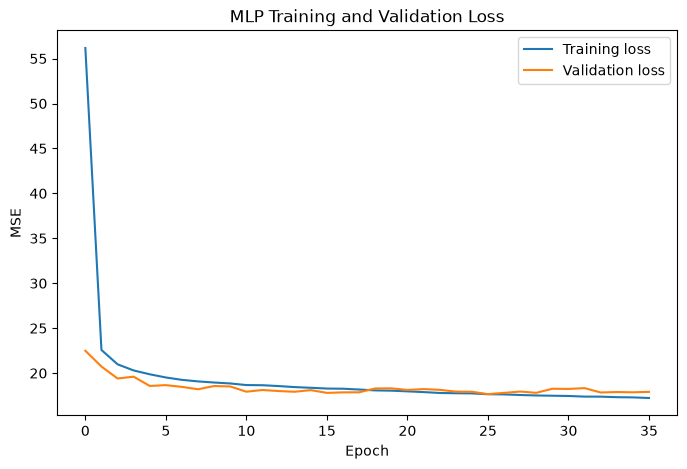

In [ ]:
# Plot training loss to visually check learning behavior
hist_df = pd.DataFrame(history.history)
plt.figure(figsize=(8, 5))
plt.plot(hist_df['loss'], label='Training loss')
plt.plot(hist_df['val_loss'], label='Validation loss')
plt.title('MLP Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [ ]:
# Adding the MLP result to the model comparison table
comparison_mlp = pd.DataFrame([
    {
        "Model": "Random Forest",
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_predictions)),
        "R2": r2_score(y_test, rf_predictions),
    },
    {
        "Model": "XGBoost",
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_predictions)),
        "R2": r2_score(y_test, xgb_predictions),
    },
    {
        "Model": "LightGBM",
        "RMSE": np.sqrt(mean_squared_error(y_test, lgbm_predictions)),
        "R2": r2_score(y_test, lgbm_predictions),
    },
    {
        "Model": "SVR",
        "RMSE": np.sqrt(mean_squared_error(y_test, svr_predictions)),
        "R2": r2_score(y_test, svr_predictions),
    },
    {
        "Model": "MLP",
        "RMSE": mlp_rmse,
        "R2": mlp_r2,
    }
]).sort_values("RMSE").reset_index(drop=True)

comparison_mlp


,Model,RMSE,R2
0,LightGBM,4.140182,0.936726
1,Random Forest,4.172310,0.935740
2,XGBoost,4.189921,0.935197
3,MLP,4.222073,0.934198
4,SVR,7.108308,0.813483


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


# We once again use the same regression metrics for the sequence model:
# - MSE is the training loss
# - MAE is tracked while training
# - RMSE and R2 are used on the test set for final comparison

# Sort by session + time
# This keeps each driving session in chronological order and avoids mixing sessions incorrectly.
df = df.sort_values(['source_file', 'Time']).reset_index(drop=True)

# Keep valid rows only
df_model = df[features + [target, 'source_file', 'Time']].dropna().copy()

# Small sample for faster testing
df_sample = df_model.iloc[::9].copy().reset_index(drop=True)

window_size = 30

X_windows = []
y_windows = []
groups = []

for session_name, session_df in df_sample.groupby('source_file'):
    X_session = session_df[features].to_numpy(dtype=np.float32)
    y_session = session_df[target].to_numpy(dtype=np.float32)

    for i in range(0, len(X_session) - window_size + 1):
        X_windows.append(X_session[i:i + window_size])
        y_windows.append(y_session[i + window_size - 1])
        groups.append(session_name)

X = np.stack(X_windows).astype(np.float32)
y = np.array(y_windows, dtype=np.float32)
group_array = np.array(groups)

# Split by session
# This makes sure that data from the same driving file stays together in either train or test.
# This is important to reduce data leakage.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=group_array))

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# Scale features
# For deep learning, scaling helps the model learn faster and more stably.
scaler = StandardScaler()
flat_train = X_train.reshape(-1, X_train.shape[-1])
flat_test = X_test.reshape(-1, X_test.shape[-1])

flat_train_scaled = scaler.fit_transform(flat_train)
flat_test_scaled = scaler.transform(flat_test)

X_train_scaled = flat_train_scaled.reshape(X_train.shape)
X_test_scaled = flat_test_scaled.reshape(X_test.shape)

# I chose a CNN with two convolution blocks: 32 filters then 64 filters.
# This is a good middle ground: enough complexity to learn temporal patterns in the sensor history,
# but still small enough to avoid overfitting on limited driving-session data.
# The max-pooling layers reduce dimension and keep the model efficient.
model = models.Sequential([
    layers.Input(shape=(window_size, len(features))),
    layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ReLU is used again because it helps the network learn nonlinear changes in airflow over time.
# It is a common default for hidden layers and works well in convolutional networks.
# I used 25 epochs with early stopping because the model usually learns quickly,
# but too many epochs can start memorizing the training sessions instead of generalizing.
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.1,
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

pred = model.predict(X_test_scaled, verbose=0).ravel()

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")


Epoch 1/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 67s 7ms/step - loss: 38.2211 - mae: 4.0690 - val_loss: 20.4409 - val_mae: 2.8385
Epoch 2/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 25.5817 - mae: 3.3972 - val_loss: 17.9280 - val_mae: 2.6228
Epoch 3/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 23.9067 - mae: 3.2509 - val_loss: 17.8153 - val_mae: 2.5822
Epoch 4/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 22.8233 - mae: 3.1455 - val_loss: 16.6190 - val_mae: 2.5143
Epoch 5/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 21.5803 - mae: 3.0349 - val_loss: 15.1708 - val_mae: 2.4917
Epoch 6/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 20.7083 - mae: 2.9565 - val_loss: 14.7157 - val_mae: 2.2947
Epoch 7/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 20.2061 - mae: 2.9061 - val_loss: 15.0551 - val_mae: 2.3089
Epoch 8/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 19.5673 - mae: 2.8362 - val_loss: 14.5563 - val_mae: 2.3740
Epoch 9/25
3414/

In [ ]:
cnn_rmse = np.sqrt(mean_squared_error(y_test, pred))
cnn_r2 = r2_score(y_test, pred)

# Use the same test length for every model so no sample-count mismatch occurs
y_test_ref = np.asarray(y_test).ravel()

model_predictions = {
    "Random Forest": np.asarray(rf_predictions).ravel(),
    "XGBoost": np.asarray(xgb_predictions).ravel(),
    "LightGBM": np.asarray(lgbm_predictions).ravel(),
    "SVR": np.asarray(svr_predictions).ravel(),
    "MLP": np.asarray(mlp_predictions).ravel() if "mlp_predictions" in globals() else None,
    "1D-CNN": np.asarray(pred).ravel(),
}

common_len = min(len(y_test_ref), *(len(v) for v in model_predictions.values() if v is not None))
y_test_aligned = y_test_ref[:common_len]

comparison_1d_cnn = pd.DataFrame(
    [
        {
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test_aligned, preds[:common_len])),
            "R2": r2_score(y_test_aligned, preds[:common_len]),
        }
        for name, preds in model_predictions.items()
        if preds is not None and len(preds) >= common_len
    ]
).sort_values("RMSE").reset_index(drop=True)

comparison_1d_cnn

comparison_1d_cnn

,Model,RMSE,R2
0,1D-CNN,3.701365,0.949537
1,SVR,17.290194,-0.101161
2,XGBoost,18.639581,-0.279745
3,LightGBM,18.659327,-0.282458
4,Random Forest,18.687103,-0.286279
5,MLP,18.780025,-0.299103


Sample rows: 310749
Sessions: 84
Windowed input shape: (308313, 30, 8)
Target shape: (308313,)
Epoch 1/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 166s 43ms/step - loss: 45.9603 - mae: 3.8060 - val_loss: 17.3677 - val_mae: 2.5844
Epoch 2/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 212s 46ms/step - loss: 18.3262 - mae: 2.7069 - val_loss: 15.6058 - val_mae: 2.4549
Epoch 3/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 151s 44ms/step - loss: 16.6094 - mae: 2.5115 - val_loss: 15.0469 - val_mae: 2.4100
Epoch 4/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 142s 42ms/step - loss: 15.4673 - mae: 2.3764 - val_loss: 13.5049 - val_mae: 2.0998
Epoch 5/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 151s 44ms/step - loss: 14.6153 - mae: 2.2653 - val_loss: 13.7083 - val_mae: 2.1120
Epoch 6/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 191s 41ms/step - loss: 13.8235 - mae: 2.1661 - val_loss: 12.4318 - val_mae: 1.9443
Epoch 7/25
3414/3414 ━━━━━━━━━━━━━━━━━━━━ 133s 39ms/step - loss: 13.3591 - mae: 2.1048 - val_loss: 12.5754 - val_mae: 1.9664
Epoch 8/25
3414/3414 ━━━━━━━━━

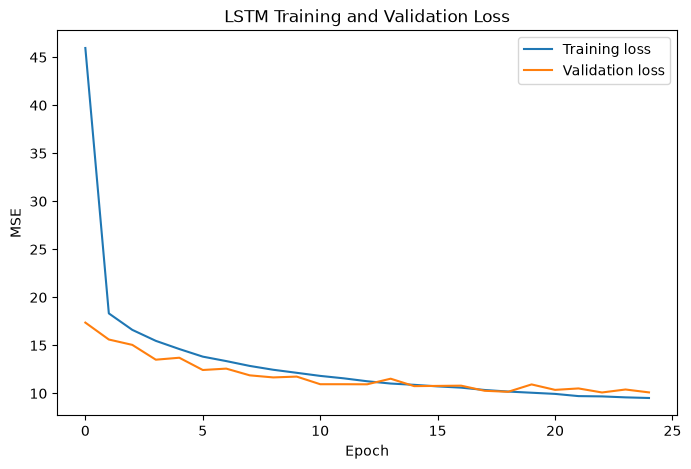

In [ ]:
# Plot learning curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [ ]:
# LSTM model for airflow prediction
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# We use the same evaluation strategy here:
# - MSE is the loss function for training
# - MAE is tracked during training for a simpler error interpretation
# - RMSE and R2 are used on the test set to compare performance with other models

# Keep only the columns needed for this model
df_lstm = df[features + [target, 'source_file', 'Time']].dropna().copy()
df_lstm = df_lstm.sort_values(['source_file', 'Time']).reset_index(drop=True)

# Use a smaller sample so the notebook runs faster
df_lstm_sample = df_lstm.iloc[::15].copy().reset_index(drop=True)

window_size = 15

X_windows = []
y_windows = []
session_groups = []

for session_name, session_df in df_lstm_sample.groupby('source_file'):
    X_session = session_df[features].to_numpy(dtype=np.float32)
    y_session = session_df[target].to_numpy(dtype=np.float32)

    for i in range(0, len(X_session) - window_size + 1):
        X_windows.append(X_session[i:i + window_size])
        y_windows.append(y_session[i + window_size - 1])
        session_groups.append(session_name)

X_lstm = np.stack(X_windows).astype(np.float32)
y_lstm = np.array(y_windows, dtype=np.float32)
groups_lstm = np.array(session_groups)

# Split by session so rows from the same driving file do not appear in both train and test.
# This helps avoid data leakage and gives a more realistic evaluation.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_lstm, y_lstm, groups=groups_lstm))

X_train_lstm = X_lstm[train_idx]
X_test_lstm = X_lstm[test_idx]
y_train_lstm = y_lstm[train_idx]
y_test_lstm = y_lstm[test_idx]

# Scale the data
# LSTM models train more steadily when the input values are on a similar scale.
scaler = StandardScaler()
flat_train = X_train_lstm.reshape(-1, X_train_lstm.shape[-1])
flat_test = X_test_lstm.reshape(-1, X_test_lstm.shape[-1])

flat_train_scaled = scaler.fit_transform(flat_train)
flat_test_scaled = scaler.transform(flat_test)

X_train_lstm_scaled = flat_train_scaled.reshape(X_train_lstm.shape)
X_test_lstm_scaled = flat_test_scaled.reshape(X_test_lstm.shape)

# I chose a relatively small LSTM architecture: 32 LSTM cells, then 16 cells.
# This is enough to learn time patterns in the sensor sequence, but not too large for a limited dataset.
# A very large LSTM can easily overfit because it has many trainable parameters.
model = models.Sequential([
    layers.Input(shape=(window_size, len(features))),
    layers.LSTM(32, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(16),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# ReLU is used in the dense output layer after the LSTM because the airflow prediction is a positive continuous value,
# and ReLU is a common activation for nonlinear hidden layers.
# I used 10 epochs because LSTM is computationally heavier than the earlier models,
# and I wanted to keep training time reasonable while still allowing the model to learn.
# Early stopping is included to stop training if the validation loss stops improving.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm_scaled,
    y_train_lstm,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=0
)

pred_lstm = model.predict(X_test_lstm_scaled, verbose=0).ravel()

lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm, pred_lstm))
lstm_r2 = r2_score(y_test_lstm, pred_lstm)

print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM R2: {lstm_r2:.4f}")


LSTM RMSE: 4.0207
LSTM R2: 0.9405
